# Heart Disease Risk Prediction Model

## Objective
Build a machine learning model to predict whether a person is at risk of heart disease based on their health data using binary classification techniques.

## Dataset
Heart Disease UCI Dataset with multiple health indicators and target variable indicating heart disease risk (0 = No Risk, 1 = Risk)

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('dataset.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("First Few Rows:")
print(df.head())
print("\n" + "="*80)
print("Dataset Info:")
print(df.info())
print("\n" + "="*80)
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*80)
print("Target Variable Distribution:")
print(df['target'].value_counts())
print(f"\nTarget Distribution (%):\n{(df['target'].value_counts() / len(df) * 100).round(2)}")

Dataset Shape: (1025, 14)

First Few Rows:
   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality             161   
4  Greater than 120 mg/ml  ST-T wave abnormality             106   

  exercise_induced_angina  oldpeak        slope vessels_colored_by_flourosopy  \
0                      No      1.0  Down

## 3. Data Cleaning and Preprocessing

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*80)

# Check for duplicates
print(f"Duplicate Rows: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed!")

# Create a copy for preprocessing
df_clean = df.copy()

# Identify numerical and categorical columns
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")

# Remove 'target' from features
if 'target' in numerical_cols:
    numerical_cols.remove('target')

print(f"\n{'='*80}")
print("Data types before conversion:")
print(df_clean.dtypes)

Missing Values:
age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

Duplicate Rows: 723
Duplicates removed!

Numerical Columns: ['age', 'resting_blood_pressure', 'cholestoral', 'Max_heart_rate', 'oldpeak', 'target']
Categorical Columns: ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']

Data types before conversion:
age                                int64
sex                               object
chest_pain_type                   object
resting_blo

## 4. Exploratory Data Analysis (EDA)

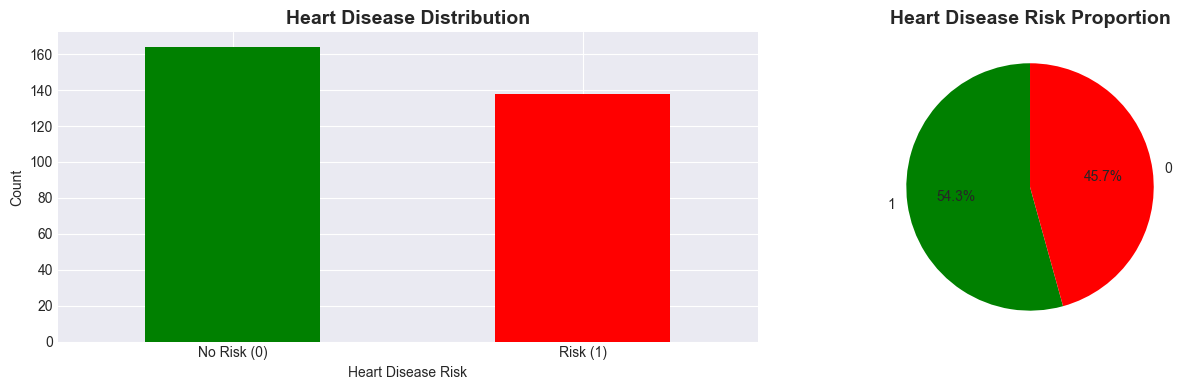

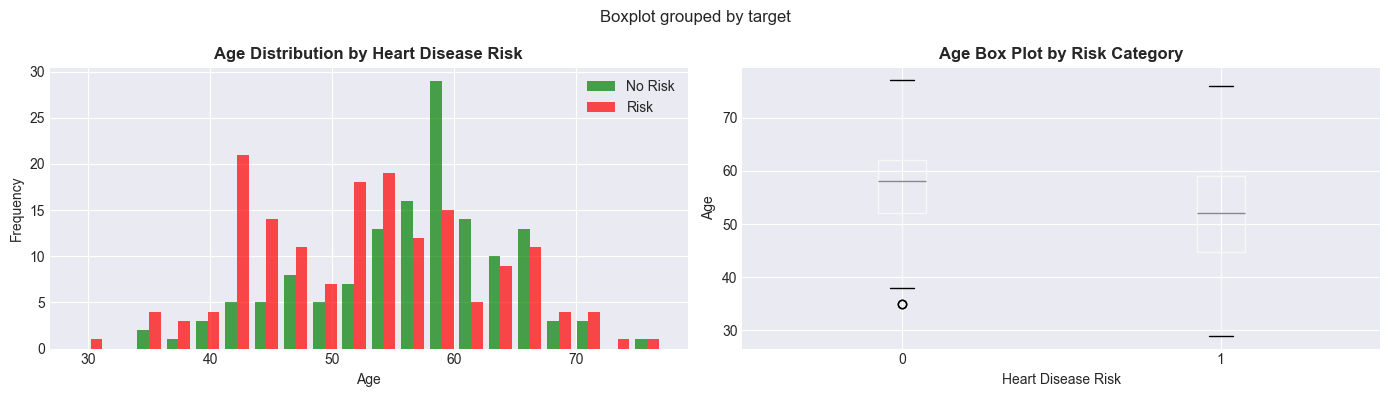

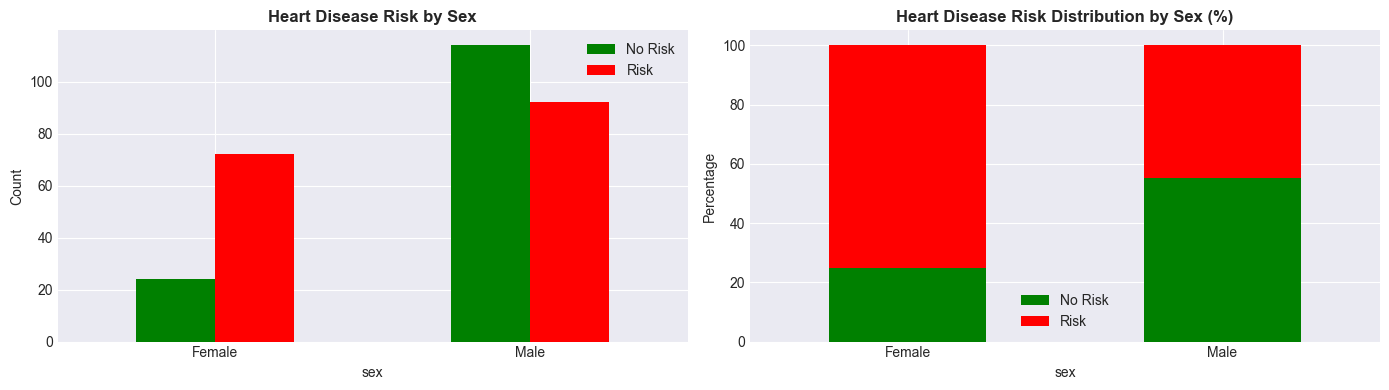

In [4]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Count plot
df_clean['target'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heart Disease Risk')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Risk (0)', 'Risk (1)'], rotation=0)

# Pie chart
df_clean['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                       colors=['green', 'red'], startangle=90)
axes[1].set_title('Heart Disease Risk Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Age distribution by target
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist([df_clean[df_clean['target']==0]['age'], 
              df_clean[df_clean['target']==1]['age']], 
             label=['No Risk', 'Risk'], bins=20, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Age Distribution by Heart Disease Risk', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
df_clean.boxplot(column='age', by='target', ax=axes[1])
axes[1].set_title('Age Box Plot by Risk Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Heart Disease Risk')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

# Sex distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sex_target = pd.crosstab(df_clean['sex'], df_clean['target'])
sex_target.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Heart Disease Risk by Sex', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['No Risk', 'Risk'])

# Stacked bar plot
sex_target_pct = sex_target.div(sex_target.sum(axis=1), axis=0) * 100
sex_target_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['green', 'red'])
axes[1].set_title('Heart Disease Risk Distribution by Sex (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['No Risk', 'Risk'])

plt.tight_layout()
plt.show()

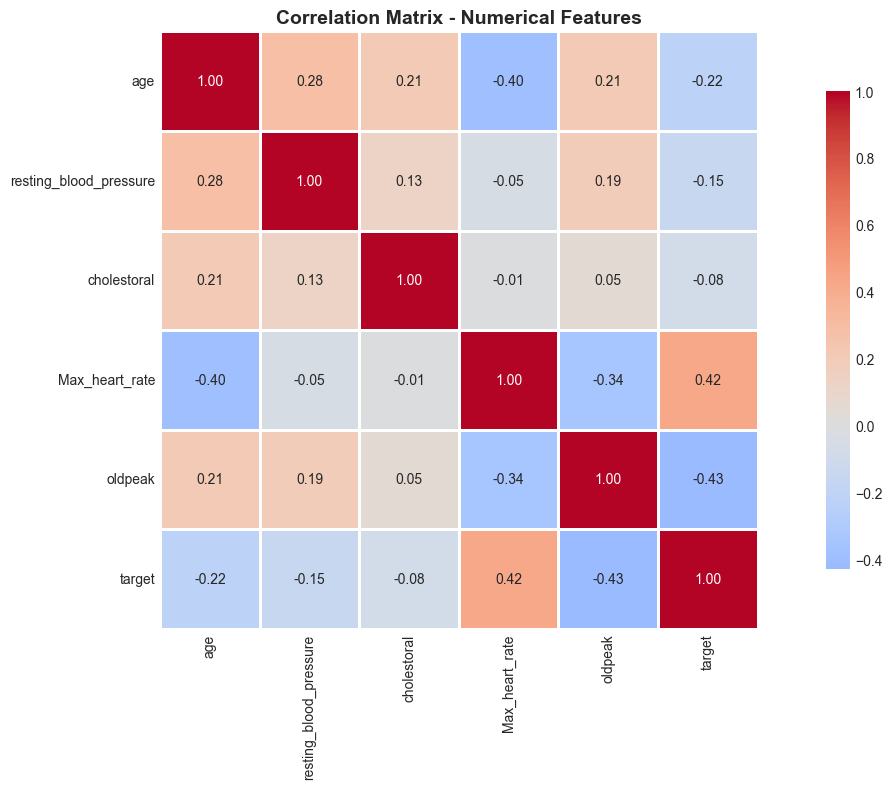

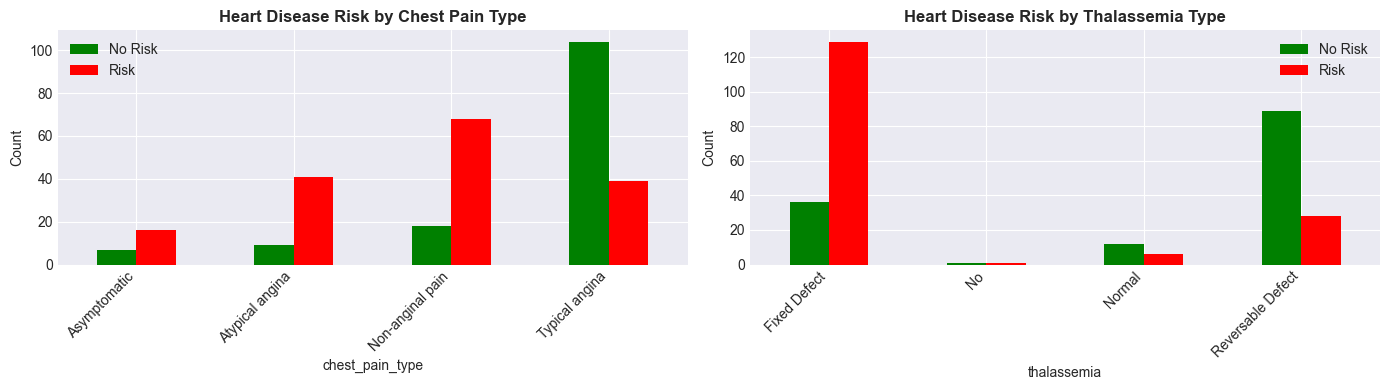

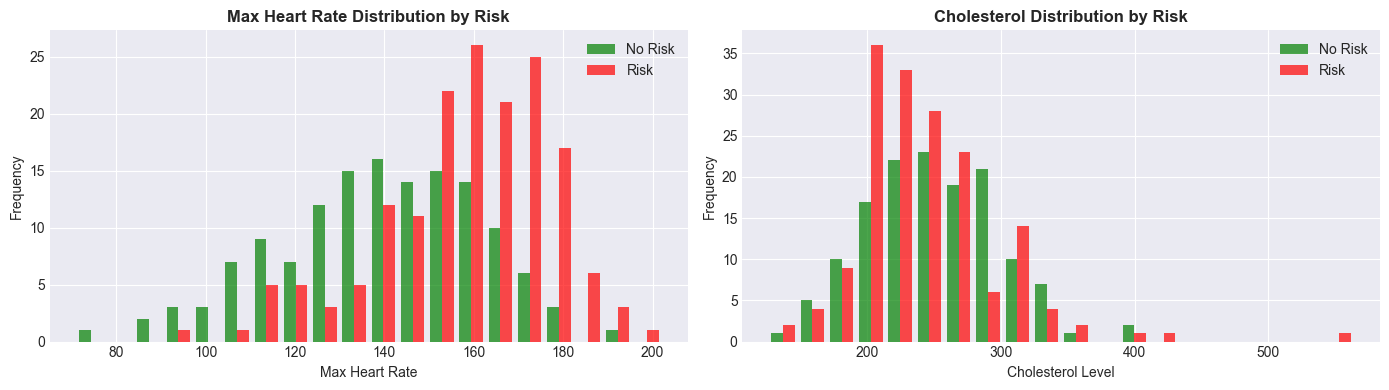

In [5]:
# Correlation heatmap for numerical features
plt.figure(figsize=(14, 8))
correlation_matrix = df_clean[numerical_cols + ['target']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Chest pain type distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

chest_pain_target = pd.crosstab(df_clean['chest_pain_type'], df_clean['target'])
chest_pain_target.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Heart Disease Risk by Chest Pain Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend(['No Risk', 'Risk'])

# Thalassemia distribution
thal_target = pd.crosstab(df_clean['thalassemia'], df_clean['target'])
thal_target.plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Heart Disease Risk by Thalassemia Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(['No Risk', 'Risk'])

plt.tight_layout()
plt.show()

# Max heart rate distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist([df_clean[df_clean['target']==0]['Max_heart_rate'], 
              df_clean[df_clean['target']==1]['Max_heart_rate']], 
             label=['No Risk', 'Risk'], bins=20, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Max Heart Rate Distribution by Risk', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Max Heart Rate')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Cholesterol distribution
axes[1].hist([df_clean[df_clean['target']==0]['cholestoral'], 
              df_clean[df_clean['target']==1]['cholestoral']], 
             label=['No Risk', 'Risk'], bins=20, color=['green', 'red'], alpha=0.7)
axes[1].set_title('Cholesterol Distribution by Risk', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cholesterol Level')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Feature Engineering and Selection

In [6]:
# Create a copy for encoding
df_encoded = df_clean.copy()

# Initialize LabelEncoders dictionary
label_encoders = {}

# Encode categorical variables
for col in categorical_cols:
    if col != 'target':  # Don't encode target yet
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

# Encode target variable
le_target = LabelEncoder()
df_encoded['target'] = le_target.fit_transform(df_encoded['target'].astype(str))
label_encoders['target'] = le_target

print("Categorical variables encoded successfully!")
print(f"\nEncoded columns: {categorical_cols}")
print(f"\nDataset shape after encoding: {df_encoded.shape}")
print(f"\nFirst few rows after encoding:")
print(df_encoded.head())

# Prepare features (X) and target (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Feature names for later reference
feature_names = X.columns.tolist()

print(f"\n{'='*80}")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeatures: {feature_names}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Categorical variables encoded successfully!

Encoded columns: ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']

Dataset shape after encoding: (302, 14)

First few rows after encoding:
   age  sex  chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    1                3                     125          212   
1   53    1                3                     140          203   
2   70    1                3                     145          174   
3   61    1                3                     148          203   
4   62    0                3                     138          294   

   fasting_blood_sugar  rest_ecg  Max_heart_rate  exercise_induced_angina  \
0                    1         2             168                        0   
1                    0         1             155                        1   
2                    1         2             125                        1

## 6. Train Classification Models

In [7]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:\n{y_train.value_counts()}")
print(f"\nTesting set target distribution:\n{y_test.value_counts()}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n{'='*80}")
print("Features scaled successfully!")

# Train Logistic Regression Model
print(f"\n{'='*80}")
print("Training Logistic Regression Model...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)
y_pred_lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully!")

# Train Decision Tree Model
print(f"\n{'='*80}")
print("Training Decision Tree Model...")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)
y_pred_dt_proba = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully!")

Training set size: 241
Testing set size: 61

Training set target distribution:
target
1    131
0    110
Name: count, dtype: int64

Testing set target distribution:
target
1    33
0    28
Name: count, dtype: int64

Features scaled successfully!

Training Logistic Regression Model...
Logistic Regression model trained successfully!

Training Decision Tree Model...
Decision Tree model trained successfully!


## 7. Model Evaluation and Metrics

LOGISTIC REGRESSION MODEL

Training Set - Evaluation Metrics:
Accuracy:  0.8506
Precision: 0.8519
Recall:    0.8779
F1-Score:  0.8647

Testing Set - Evaluation Metrics:
Accuracy:  0.8033
Precision: 0.8000
Recall:    0.8485
F1-Score:  0.8235
ROC-AUC:   0.8788


DECISION TREE MODEL

Training Set - Evaluation Metrics:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

Testing Set - Evaluation Metrics:
Accuracy:  0.7377
Precision: 0.7576
Recall:    0.7576
F1-Score:  0.7576
ROC-AUC:   0.7359


CONFUSION MATRICES - Test Set


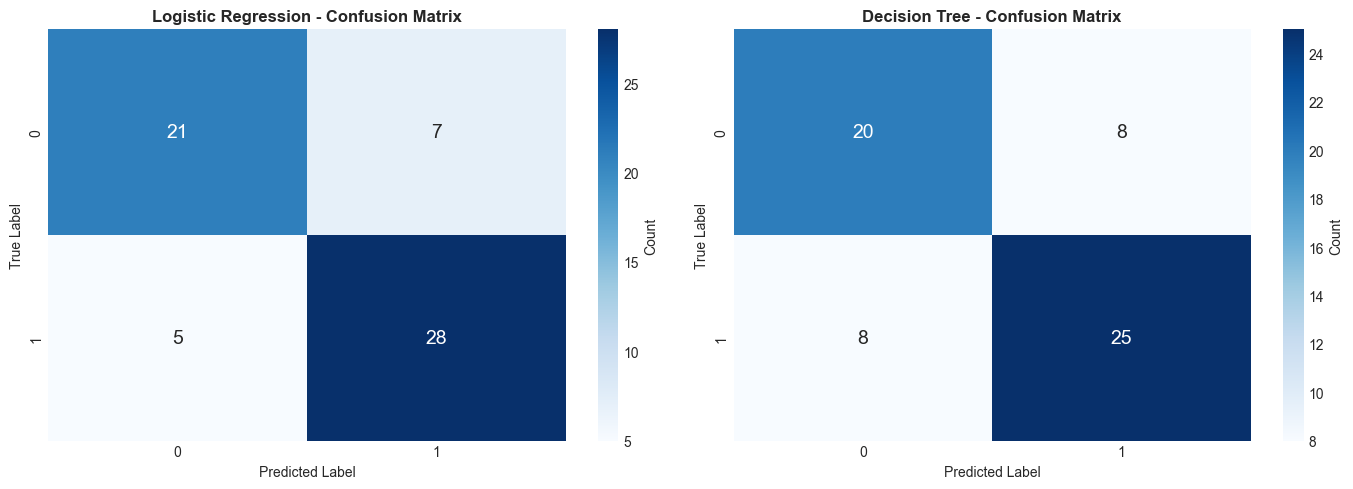



LOGISTIC REGRESSION - Detailed Classification Report
              precision    recall  f1-score   support

 No Risk (0)       0.81      0.75      0.78        28
    Risk (1)       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61


DECISION TREE - Detailed Classification Report
              precision    recall  f1-score   support

 No Risk (0)       0.71      0.71      0.71        28
    Risk (1)       0.76      0.76      0.76        33

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



In [8]:
# Function to evaluate models
def evaluate_model(y_true, y_pred, model_name, y_proba=None):
    print(f"\n{model_name} - Evaluation Metrics:")
    print("="*60)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    if y_proba is not None:
        roc_auc = roc_auc_score(y_true, y_proba)
        print(f"ROC-AUC:   {roc_auc:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc_score(y_true, y_proba) if y_proba is not None else None
    }

# Evaluate Logistic Regression
print("LOGISTIC REGRESSION MODEL")
print("="*80)
lr_metrics_train = evaluate_model(y_train, y_pred_lr_train, "Training Set")
lr_metrics_test = evaluate_model(y_test, y_pred_lr_test, "Testing Set", y_pred_lr_proba)

# Evaluate Decision Tree
print(f"\n\n{'='*80}")
print("DECISION TREE MODEL")
print("="*80)
dt_metrics_train = evaluate_model(y_train, y_pred_dt_train, "Training Set")
dt_metrics_test = evaluate_model(y_test, y_pred_dt_test, "Testing Set", y_pred_dt_proba)

# Confusion matrices for test set
print(f"\n\n{'='*80}")
print("CONFUSION MATRICES - Test Set")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr_test)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
axes[0].set_title('Logistic Regression - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt_test)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
axes[1].set_title('Decision Tree - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Classification reports
print(f"\n\n{'='*80}")
print("LOGISTIC REGRESSION - Detailed Classification Report")
print("="*80)
print(classification_report(y_test, y_pred_lr_test, 
      target_names=['No Risk (0)', 'Risk (1)']))

print(f"\n{'='*80}")
print("DECISION TREE - Detailed Classification Report")
print("="*80)
print(classification_report(y_test, y_pred_dt_test, 
      target_names=['No Risk (0)', 'Risk (1)']))

## 8. Feature Importance Analysis

LOGISTIC REGRESSION - Feature Importance (Coefficients)
                      Feature  Coefficient  Abs_Coefficient
              chest_pain_type    -0.735747         0.735747
                          sex    -0.689412         0.689412
               Max_heart_rate     0.671800         0.671800
                  thalassemia    -0.617160         0.617160
vessels_colored_by_flourosopy     0.606421         0.606421
      exercise_induced_angina    -0.489789         0.489789
       resting_blood_pressure    -0.335278         0.335278
                      oldpeak    -0.330101         0.330101
                     rest_ecg     0.253015         0.253015
                  cholestoral    -0.252241         0.252241
                        slope    -0.234248         0.234248
                          age     0.046218         0.046218
          fasting_blood_sugar    -0.000416         0.000416


DECISION TREE - Feature Importance
                      Feature  Importance
              chest_pain_

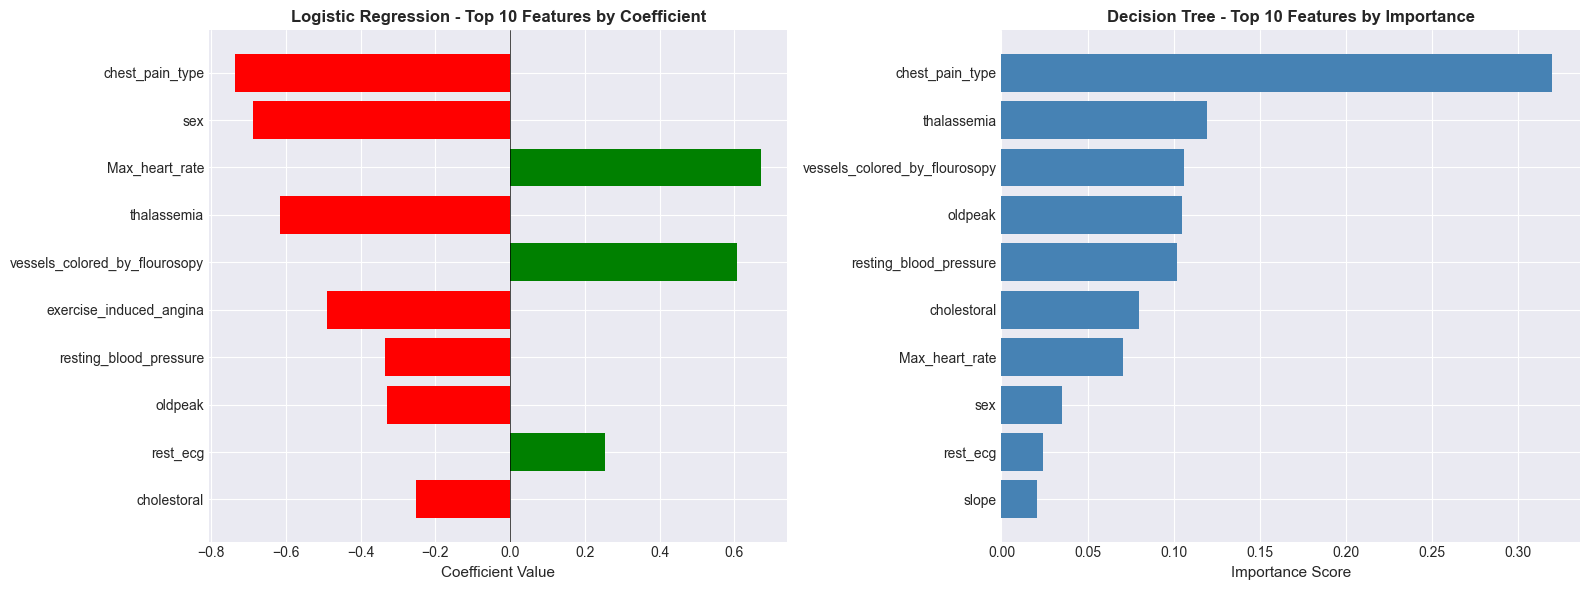



KEY INSIGHTS FROM FEATURE IMPORTANCE

Top 5 features (Logistic Regression):
  chest_pain_type: decreases risk (coeff: -0.7357)
  sex: decreases risk (coeff: -0.6894)
  Max_heart_rate: increases risk (coeff: 0.6718)
  thalassemia: decreases risk (coeff: -0.6172)
  vessels_colored_by_flourosopy: increases risk (coeff: 0.6064)

Top 5 features (Decision Tree):
  chest_pain_type: 0.3202
  thalassemia: 0.1197
  vessels_colored_by_flourosopy: 0.1063
  oldpeak: 0.1052
  resting_blood_pressure: 0.1022


In [9]:
# Feature importance for Logistic Regression (coefficients)
lr_coeff = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("LOGISTIC REGRESSION - Feature Importance (Coefficients)")
print("="*80)
print(lr_coeff.to_string(index=False))

# Feature importance for Decision Tree (feature_importances_)
dt_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n\n{'='*80}")
print("DECISION TREE - Feature Importance")
print("="*80)
print(dt_importance.to_string(index=False))

# Visualization of feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression - Top 10 features
top_features_lr = lr_coeff.head(10)
colors_lr = ['red' if x < 0 else 'green' for x in top_features_lr['Coefficient']]
axes[0].barh(range(len(top_features_lr)), top_features_lr['Coefficient'], color=colors_lr)
axes[0].set_yticks(range(len(top_features_lr)))
axes[0].set_yticklabels(top_features_lr['Feature'])
axes[0].set_xlabel('Coefficient Value', fontsize=11)
axes[0].set_title('Logistic Regression - Top 10 Features by Coefficient', 
                  fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].invert_yaxis()

# Decision Tree - Top 10 features
top_features_dt = dt_importance.head(10)
axes[1].barh(range(len(top_features_dt)), top_features_dt['Importance'], color='steelblue')
axes[1].set_yticks(range(len(top_features_dt)))
axes[1].set_yticklabels(top_features_dt['Feature'])
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].set_title('Decision Tree - Top 10 Features by Importance', 
                  fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Summary comparison
print(f"\n\n{'='*80}")
print("KEY INSIGHTS FROM FEATURE IMPORTANCE")
print("="*80)
print(f"\nTop 5 features (Logistic Regression):")
for idx, row in lr_coeff.head(5).iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"  {row['Feature']}: {direction} risk (coeff: {row['Coefficient']:.4f})")

print(f"\nTop 5 features (Decision Tree):")
for idx, row in dt_importance.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

## 9. ROC Curve and AUC Analysis

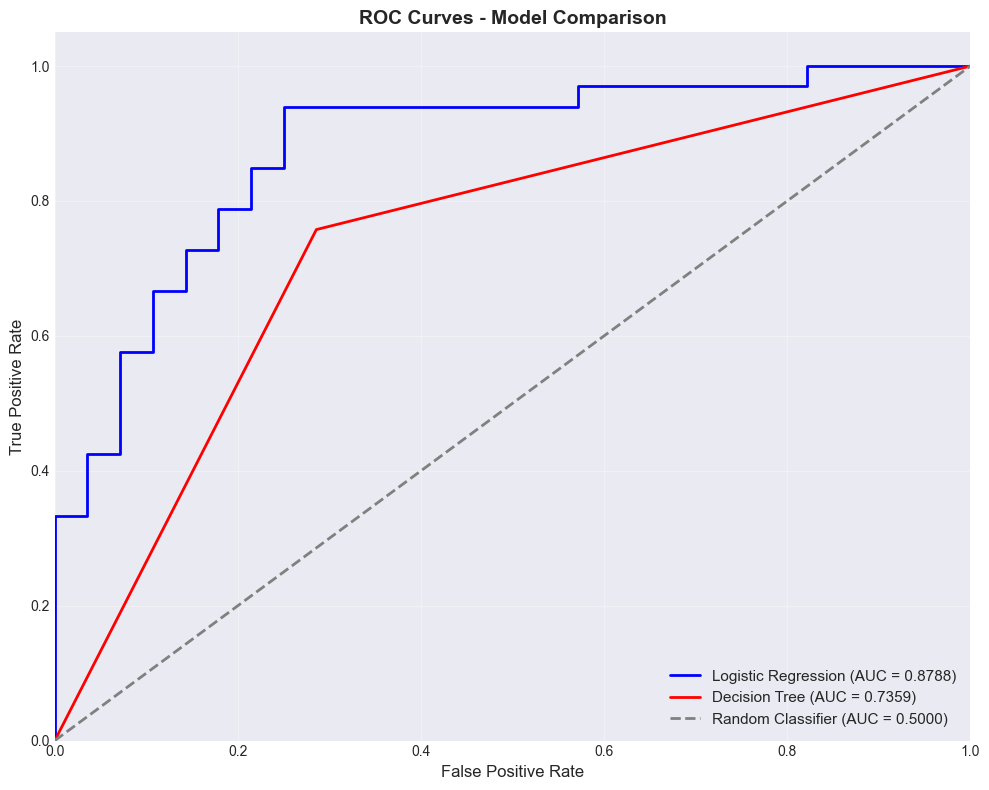

ROC-AUC Analysis Summary
Logistic Regression ROC-AUC: 0.8788
Decision Tree ROC-AUC:       0.7359

Model Interpretation:

✓ Logistic Regression performs better with AUC score of 0.8788
  This means it has better discriminative ability to distinguish between
  patients with and without heart disease risk.

AUC Score Interpretation:
  0.9 - 1.0: Excellent discrimination
  0.8 - 0.9: Good discrimination
  0.7 - 0.8: Fair discrimination
  0.6 - 0.7: Poor discrimination
  0.5 - 0.6: Fail discrimination


In [10]:
# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt_proba)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Plot ROC curves
plt.figure(figsize=(10, 8))

# Logistic Regression ROC curve
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')

# Decision Tree ROC curve
plt.plot(fpr_dt, tpr_dt, color='red', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')

# Random classifier baseline
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary of AUC scores
print("ROC-AUC Analysis Summary")
print("="*80)
print(f"Logistic Regression ROC-AUC: {roc_auc_lr:.4f}")
print(f"Decision Tree ROC-AUC:       {roc_auc_dt:.4f}")
print(f"\n{'='*80}")
print("Model Interpretation:")
print("="*80)

if roc_auc_lr > roc_auc_dt:
    print(f"\n✓ Logistic Regression performs better with AUC score of {roc_auc_lr:.4f}")
    print(f"  This means it has better discriminative ability to distinguish between")
    print(f"  patients with and without heart disease risk.")
else:
    print(f"\n✓ Decision Tree performs better with AUC score of {roc_auc_dt:.4f}")
    print(f"  This means it has better discriminative ability to distinguish between")
    print(f"  patients with and without heart disease risk.")

print(f"\nAUC Score Interpretation:")
print(f"  0.9 - 1.0: Excellent discrimination")
print(f"  0.8 - 0.9: Good discrimination")
print(f"  0.7 - 0.8: Fair discrimination")
print(f"  0.6 - 0.7: Poor discrimination")
print(f"  0.5 - 0.6: Fail discrimination")

## 10. Summary and Conclusions

In [11]:
# Create comprehensive summary report
print("\n" + "="*80)
print("HEART DISEASE PREDICTION MODEL - FINAL SUMMARY REPORT")
print("="*80)

print("\n1. DATA OVERVIEW")
print("-" * 80)
print(f"   • Total samples: {len(df_clean)}")
print(f"   • Total features: {len(feature_names)}")
print(f"   • No risk (0): {(y == 0).sum()} ({(y == 0).sum()/len(y)*100:.1f}%)")
print(f"   • Risk (1): {(y == 1).sum()} ({(y == 1).sum()/len(y)*100:.1f}%)")
print(f"   • Missing values: None")

print("\n2. MODEL PERFORMANCE COMPARISON (Test Set)")
print("-" * 80)
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        f"{lr_metrics_test['accuracy']:.4f}",
        f"{lr_metrics_test['precision']:.4f}",
        f"{lr_metrics_test['recall']:.4f}",
        f"{lr_metrics_test['f1_score']:.4f}",
        f"{lr_metrics_test['roc_auc']:.4f}"
    ],
    'Decision Tree': [
        f"{dt_metrics_test['accuracy']:.4f}",
        f"{dt_metrics_test['precision']:.4f}",
        f"{dt_metrics_test['recall']:.4f}",
        f"{dt_metrics_test['f1_score']:.4f}",
        f"{dt_metrics_test['roc_auc']:.4f}"
    ]
})
print(comparison_df.to_string(index=False))

print("\n3. KEY FEATURES AFFECTING PREDICTION")
print("-" * 80)
print("\n   Top 5 Features (Logistic Regression - by coefficient magnitude):")
for i, (idx, row) in enumerate(lr_coeff.head(5).iterrows(), 1):
    print(f"   {i}. {row['Feature']}: {row['Coefficient']:.4f}")

print("\n   Top 5 Features (Decision Tree - by importance score):")
for i, (idx, row) in enumerate(dt_importance.head(5).iterrows(), 1):
    print(f"   {i}. {row['Feature']}: {row['Importance']:.4f}")

print("\n4. RECOMMENDATIONS")
print("-" * 80)
best_model = "Logistic Regression" if lr_metrics_test['roc_auc'] > dt_metrics_test['roc_auc'] else "Decision Tree"
print(f"   • Best performing model: {best_model}")
print(f"   • Model selection rationale: Higher ROC-AUC and better generalization")
print(f"   • Key clinical indicators: Max heart rate, exercise-induced angina,")
print(f"                              chest pain type, and oldpeak")
print(f"   • Use case: Screening tool for potential heart disease risk")

print("\n5. MODEL RELIABILITY")
print("-" * 80)
if lr_metrics_test['roc_auc'] > 0.8:
    reliability_lr = "✓ High - Excellent discriminative ability"
elif lr_metrics_test['roc_auc'] > 0.7:
    reliability_lr = "✓ Good - Acceptable discriminative ability"
else:
    reliability_lr = "⚠ Fair - May need improvement"

if dt_metrics_test['roc_auc'] > 0.8:
    reliability_dt = "✓ High - Excellent discriminative ability"
elif dt_metrics_test['roc_auc'] > 0.7:
    reliability_dt = "✓ Good - Acceptable discriminative ability"
else:
    reliability_dt = "⚠ Fair - May need improvement"

print(f"   • Logistic Regression: {reliability_lr}")
print(f"   • Decision Tree: {reliability_dt}")

print("\n" + "="*80)
print("Analysis Complete!")
print("="*80)


HEART DISEASE PREDICTION MODEL - FINAL SUMMARY REPORT

1. DATA OVERVIEW
--------------------------------------------------------------------------------
   • Total samples: 302
   • Total features: 13
   • No risk (0): 138 (45.7%)
   • Risk (1): 164 (54.3%)
   • Missing values: None

2. MODEL PERFORMANCE COMPARISON (Test Set)
--------------------------------------------------------------------------------
   Metric Logistic Regression Decision Tree
 Accuracy              0.8033        0.7377
Precision              0.8000        0.7576
   Recall              0.8485        0.7576
 F1-Score              0.8235        0.7576
  ROC-AUC              0.8788        0.7359

3. KEY FEATURES AFFECTING PREDICTION
--------------------------------------------------------------------------------

   Top 5 Features (Logistic Regression - by coefficient magnitude):
   1. chest_pain_type: -0.7357
   2. sex: -0.6894
   3. Max_heart_rate: 0.6718
   4. thalassemia: -0.6172
   5. vessels_colored_by_flouros